In [3]:
import numpy as np
from keras.datasets.mnist import load_data
from keras.layers import Dense,Dropout,LeakyReLU,Reshape,Conv2DTranspose,Conv2D,Flatten
from keras.optimizers import Adam
from keras.models import Sequential
import matplotlib.pyplot as plt
from keras.utils import plot_model

I0000 00:00:1783593726.001521  850046 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
(trainX,trainy),(testX,testy)=load_data()

In [5]:
trainX.shape

(60000, 28, 28)

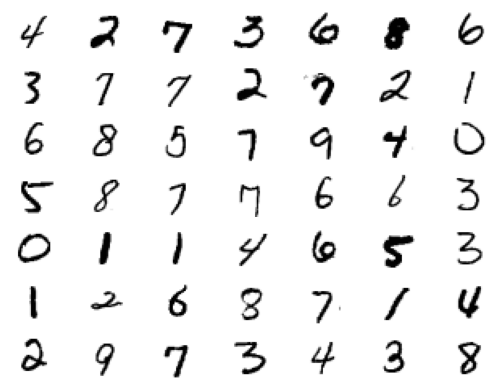

In [6]:
for i,j in enumerate(np.random.randint(0,trainX.shape[0],49)):
    plt.subplot(7,7,i+1)
    plt.imshow(trainX[j],cmap='gray_r')
    plt.axis('off')
plt.show()

In [13]:
def define_discriminator(in_shape=(28,28,1)):
    model = Sequential()
    model.add(Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),padding='same',input_shape=in_shape))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.4))
    model.add(Conv2D(64,(3,3),strides=(2,2),padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.4))
    model.add(Flatten())
    model.add(Dense(1,activation='sigmoid'))
    opt = Adam(learning_rate=0.002,beta_1=0.5)
    model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])
    return model

/raid/home/srinivasan/Learning_GAN/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,705 (159.00 KB)

 Trainable params: 40,705 (159.00 KB)

 Non-trainable params: 0 (0.00 B)

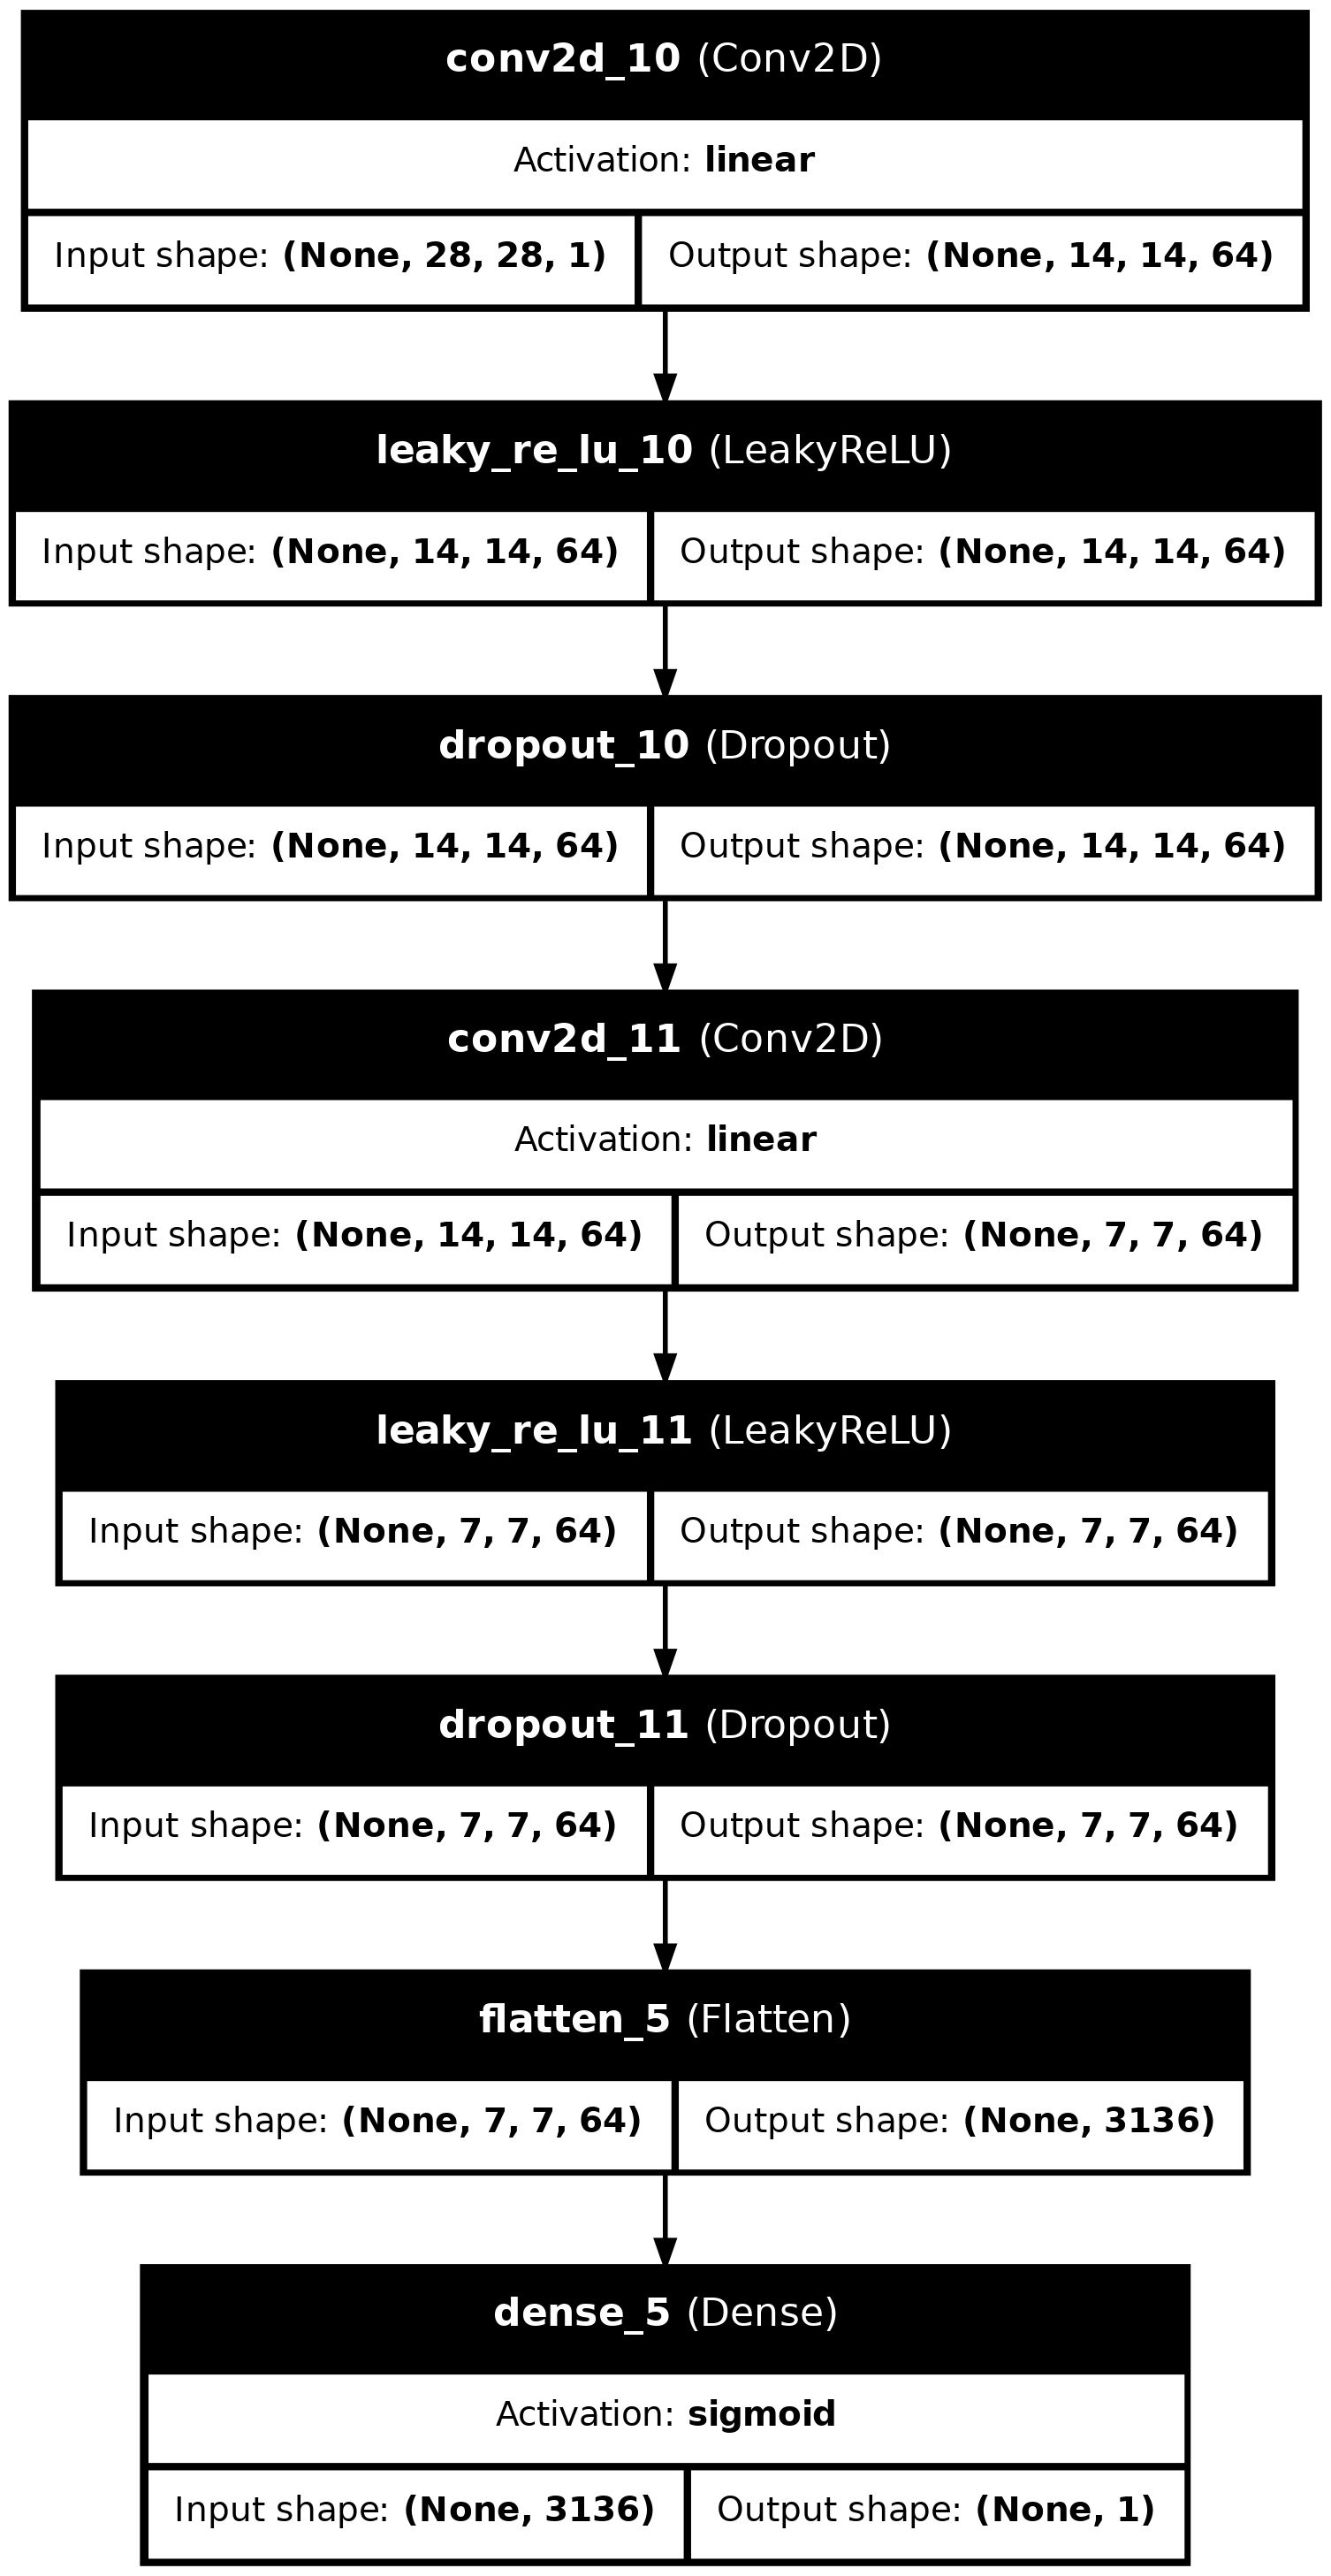

In [14]:
model=define_discriminator()
model.summary()
plot_model(model,to_file='Discriminator.png',show_layer_names=True,show_shapes=True,show_layer_activations=True)

In [44]:
def load_real_samples():
    (trainX,_),(_,_)= load_data()
    X =np.expand_dims(trainX,axis=-1)
    X= X.astype('float32')
    X= X/255.0
    return X

In [45]:
datasets = load_real_samples()
datasets.shape
# datasets[0]
# plt.imshow(datasets[0])

(60000, 28, 28, 1)

In [49]:
def generate_real_samples(datasets,n_sample):
    img = np.random.randint(0,datasets.shape[0],n_sample)
    X= datasets[img]
    y= np.ones((n_sample,1))
    return X,y

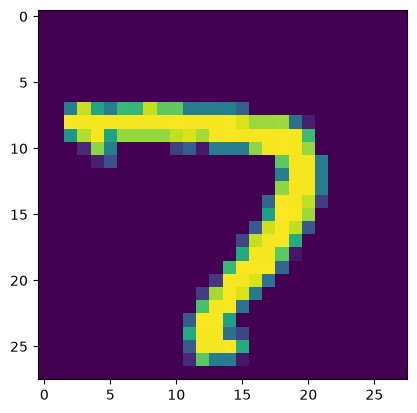

In [55]:
images , labels = generate_real_samples(datasets,100)
images.shape
plt.imshow(images[0])

In [54]:
labels.shape

(100, 1)

In [58]:
def generate_fake_samples(n_samples):
    X= np.random.rand(28*28*n_samples)
    X = X.reshape((n_samples,28,28,1))
    y=np.zeros((n_samples,1))
    return X,y

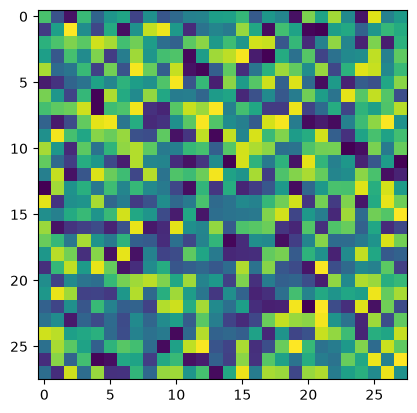

In [66]:
new_X,label = generate_fake_samples(1000)
plt.imshow(new_X[0])

In [69]:
def train_discriminator(model,datasets,n_iter=100,n_batches=256):
    half_batch = int(n_batches/2)
    for i in range(n_iter):
        #generate new samples 
        X_real, y_real = generate_real_samples(datasets,half_batch)
        #update discrimanator on real samples(weights updates)
        _,real_acc=model.train_on_batch(X_real,y_real)
        X_fake,y_fake = generate_fake_samples(half_batch)
        #updating the discriminator on fake samples
        _, fake_acc = model.train_on_batch(X_fake,y_fake)
        #yahan par model ka summarisations
        print(f'{i+1} Epochs | Real Accuracy :{real_acc*100} | Fake Accuracy :{fake_acc*100}')

In [70]:
model = define_discriminator()
datasets= load_real_samples()
d_model = train_discriminator(model,datasets)

/raid/home/srinivasan/Learning_GAN/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1 Epochs | Real Accuracy :53.125 | Fake Accuracy :0.0
2 Epochs | Real Accuracy :96.875 | Fake Accuracy :68.75
3 Epochs | Real Accuracy :89.0625 | Fake Accuracy :100.0
4 Epochs | Real Accuracy :91.40625 | Fake Accuracy :100.0
5 Epochs | Real Accuracy :89.84375 | Fake Accuracy :100.0
6 Epochs | Real Accuracy :99.21875 | Fake Accuracy :100.0
7 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
8 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
9 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
10 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
11 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
12 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
13 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
14 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
15 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
16 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
17 Epochs | Real Accuracy :100.0 | Fake Accuracy :100.0
18 Epochs | Real Accuracy :100.0 | Fake Accura